# 03 · The 12-Month Simulation

**Purpose.** Notebooks 03 and 04 answer what happens on a trip. This one answers the question leadership actually asked: **over the next twelve months, at each price, how much revenue does the business make, and how wrong could that be?**

A single expected-value calculation cannot answer the second half. Point estimates invite a decision to be made as if the number were certain, and the whole reason this analysis exists is that nobody could previously say how much risk a price change carried.

**Four sources of uncertainty, deliberately separated**

| Source | Correlated across accounts? | Why it matters |
|---|---|---|
| Macroeconomic path | **Yes** | Moves how much travel happens at all |
| Market share | **Yes** | Moves whose travel is ours to price |
| Behavioral response | No | Each account draws its own state |
| Departure rate | **Yes** | Rare, expensive, and poorly estimated |

**The correlation is the entire point.** Drawing each account independently would let good and bad outcomes cancel across 50,000 accounts, and the revenue distribution would collapse to a spike. That would report a precision the analysis has not earned. Macro and share draws are therefore made **once per iteration** and applied to everyone, which is what produces an honest spread.

**Two known biases, both pushing the same way**

Notebook 01 §6.2 found the price response under-stated out of region; notebook 02 §5 found reduction depth under-stated by label contamination. Both make a price rise look safer than it is. Every scenario is therefore run **twice** — as fitted, and with both corrections applied — and the recommendation is read off the conservative case.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data/synthetic")


def load(name):
    pq, csv = DATA / f"{name}.parquet", DATA / f"{name}.csv"
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"{name} not found — run data/00_generate_and_validate_data.ipynb and notebooks 01–02 first.")


accounts = load("accounts")
macro = load("macro")
trips = load("trips").merge(accounts, on="account_id", how="left")
scored = load("scored_trips")
rev_tbl = load("revenue_by_state")
model_meta = load("model_meta").set_index("key")["value"]
mag_meta = load("magnitude_meta").set_index("key")["value"]

CLASSES = ["no_purchase", "reduces", "unchanged", "increases"]
GRID = np.round(np.sort(rev_tbl["price_multiplier"].unique()), 4)

RESPONSE_RATIO = float(model_meta.get("response_ratio", 1.0))
DEPTH_BIAS = float(mag_meta.get("depth_bias", 1.0))
DEP_LO = float(model_meta.get("departure_lo", 0.002))
DEP_HI = float(model_meta.get("departure_hi", 0.006))

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9})
INK, ACCENT, MUTED = "#201e1d", "#1c4ed8", "#9a9694"

print(f"price grid: {GRID[0]:.3f} to {GRID[-1]:.3f} in {len(GRID)} steps")
print(f"response ratio (03 §6.2): {RESPONSE_RATIO:.2f}x")
print(f"depth bias     (04 §5)  : {DEPTH_BIAS:.2f}x")
print(f"departure rate 95% CI   : {DEP_LO:.4%} to {DEP_HI:.4%}")

price grid: 0.900 to 1.200 in 13 steps
response ratio (03 §6.2): 1.87x
depth bias     (04 §5)  : 1.06x
departure rate 95% CI   : 0.6687% to 0.8734%


---
## 1 · What a departure actually costs

The revenue table books `no_purchase` at zero, which is right for the pass and wrong for the relationship. A customer who substitutes an eSIM costs one trip's pass revenue. A customer who **leaves** costs their entire ARPU across every product for as long as they would have stayed — and that loss lands outside the roaming P&L, which is exactly why a roaming-only analysis tends to miss it.

The figures below are illustrative rather than drawn from any real book. They are set explicitly so the assumption is visible and can be argued with, rather than buried in a constant.

**Why this matters more than its size suggests.** Departure is rare, so it barely moves the median. It is expensive, so it dominates the left tail — and the left tail is what a pricing decision is actually risking.

In [2]:
# --- illustrative, stated openly ---
ARPU_CONSUMER, ARPU_BUSINESS = 65.0, 95.0     # $/line/month
RETAINED_MONTHS = 24                            # horizon over which a lost account is counted

acct = accounts[["account_id", "is_business", "lines_on_account"]].copy()
acct["monthly_arpu"] = acct["lines_on_account"] * np.where(
    acct["is_business"], ARPU_BUSINESS, ARPU_CONSUMER)
acct["departure_cost"] = acct["monthly_arpu"] * RETAINED_MONTHS

print(f"Mean value of a lost account: ${acct.departure_cost.mean():,.0f}")
print(f"  consumer ${acct.loc[~acct.is_business, 'departure_cost'].mean():,.0f}   "
      f"business ${acct.loc[acct.is_business, 'departure_cost'].mean():,.0f}")

travellers = trips["account_id"].unique()
mean_trip_rev = trips.loc[trips.pass_revenue > 0, "pass_revenue"].mean()
print(f"\nFor scale: one lost account is worth about "
      f"{acct.departure_cost.mean() / mean_trip_rev:.0f} pass purchases.")
print("A price rise that adds a few dollars per trip and costs a handful of")
print("relationships can be net negative without ever looking like it.")

Mean value of a lost account: $4,118
  consumer $3,293   business $7,000

For scale: one lost account is worth about 65 pass purchases.
A price rise that adds a few dollars per trip and costs a handful of
relationships can be net negative without ever looking like it.


---
## 2 · Building the forward year

The simulation projects the *next* twelve months, so it needs a forward trip panel rather than the historical one. Each account's trip pattern is carried forward and re-seasonalised, and the macro path is regenerated per iteration.

Two modelling choices worth naming:

- **Trip volume scales, trips do not get invented.** Each historical trip is carried forward with a probability set by the macro and share draws, rather than generating new synthetic trips with new characteristics. That keeps the account mix stable and confines the uncertainty to volume, which is where the evidence actually is.
- **Seasonality is reapplied, not inherited.** The historical window covers two years with its own macro path; reusing it would bake one realisation of the economy into every iteration.

In [3]:
# Forward panel: the most recent 12 months of trips, re-indexed to months 0-11
last12 = trips[trips["month"] >= trips["month"].max() - 11].copy()
last12["fwd_month"] = last12["month"] - last12["month"].min()

# Strip the historical macro effect so it can be redrawn per iteration
hist_mult = macro.set_index("month")["travel_multiplier"]
last12["hist_macro_mult"] = last12["month"].map(hist_mult).to_numpy()

# Seasonality for the forward year, macro-free
fwd_season = 1.0 + 0.15 * np.sin(2 * np.pi * (np.arange(12) - 2) / 12) \
             + 0.06 * (np.arange(12) == 11)

rev_wide = rev_tbl.pivot_table(index="trip_id", columns="price_multiplier",
                               values=[f"rev_{c}" for c in CLASSES])
prob_wide = scored.set_index("trip_id")[[f"p_{c}" for c in CLASSES]]

panel = last12[["trip_id", "account_id", "fwd_month", "is_business",
                "lines_traveling", "days_traveled"]].copy()
panel = panel[panel["trip_id"].isin(prob_wide.index) & panel["trip_id"].isin(rev_wide.index)]
panel = panel.merge(acct[["account_id", "departure_cost"]], on="account_id", how="left")
panel["season"] = fwd_season[panel["fwd_month"].to_numpy()]
panel["hist_macro_mult"] = last12.set_index("trip_id").loc[panel.trip_id, "hist_macro_mult"].to_numpy()

print(f"forward panel: {len(panel):,} trips across {panel.account_id.nunique():,} accounts")
print(f"months 0-11, seasonality range {fwd_season.min():.2f} to {fwd_season.max():.2f}")

forward panel: 51,838 trips across 22,133 accounts
months 0-11, seasonality range 0.87 to 1.15


---
## 3 · The simulation

One iteration:

1. Draw an **AR(1) macro path** for twelve months — one path, shared by every account.
2. Draw a **market share drift** — also shared.
3. Draw a **departure rate** from the bootstrapped interval in notebook 01 §10.
4. For each trip, decide whether it happens (macro × share × seasonality), then **draw its state** from the model's probabilities at the chosen price.
5. Sum pass revenue, subtract the value of accounts lost.

Steps 1–3 are drawn once per iteration; step 4 is drawn per trip. That distinction is the difference between an honest distribution and a spike.

**Antithetic pairing** halves the variance for free: each macro path is run alongside its mirror image, so a strong economy and a weak one appear in equal measure rather than by luck of the draw.

In [4]:
N_ITER = 400

TRIP_IDS = panel["trip_id"].to_numpy()
P_BASE = np.column_stack([prob_wide.loc[TRIP_IDS, f"p_{c}"].to_numpy() for c in CLASSES])
SEASON = panel["season"].to_numpy()
HIST_M = panel["hist_macro_mult"].to_numpy()
ACCT = panel["account_id"].to_numpy()
DEP_COST = panel["departure_cost"].to_numpy()
MONTH = panel["fwd_month"].to_numpy()
N = len(panel)

_uniq_acct, ACCT_IX = np.unique(ACCT, return_inverse=True)
N_ACCT = len(_uniq_acct)
ACCT_COST = (pd.Series(DEP_COST).groupby(ACCT_IX).first().to_numpy())


def rev_at(mult, depth_scale=1.0):
    """(n, 4) revenue per state at the nearest grid price."""
    m = GRID[np.argmin(np.abs(GRID - mult))]
    R = np.column_stack([rev_wide[(f"rev_{c}", m)].loc[TRIP_IDS].to_numpy() for c in CLASSES])
    if depth_scale != 1.0:
        j = CLASSES.index("reduces")
        full = R[:, CLASSES.index("unchanged")]
        R = R.copy()
        R[:, j] = np.clip(full - depth_scale * (full - R[:, j]), 0, None)
    return R


# State probabilities per price come from the sweep applied to each trip's own
# baseline: shift the log-odds by the population change, preserving heterogeneity.
sweep = load("price_sweep").set_index("price_multiplier")


def _logp(p):
    """Log-probability, the correct scale for a multiclass shift.

    An earlier version used logit() here. softmax(logit(p)) renormalises the
    ODDS rather than the probabilities, so a 0.099 walk-away risk came back
    as 0.036 and the whole simulation ran on understated churn.
    """
    return np.log(np.clip(p, 1e-9, 1.0))


P_STD = P_BASE / P_BASE.sum(axis=1, keepdims=True)
SHIFT = {}
for m in GRID:
    j = np.argmin(np.abs(sweep.index.to_numpy() - m))
    tgt = sweep.iloc[j][CLASSES].to_numpy()
    ref = sweep.iloc[np.argmin(np.abs(sweep.index.to_numpy() - 1.0))][CLASSES].to_numpy()
    SHIFT[float(m)] = _logp(tgt) - _logp(ref)


def probs_at(mult, response_scale=1.0):
    m = float(GRID[np.argmin(np.abs(GRID - mult))])
    Z = _logp(P_STD) + response_scale * SHIFT[m]
    E = np.exp(Z - Z.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)


print("probability shift table built for", len(SHIFT), "price points")

# --- join guard -------------------------------------------------------------
# At x1.00 the shift is exactly zero, so probs_at(1.0) must reproduce the
# scored probabilities. If it does not, the panel join has dropped or
# misaligned rows, and every downstream dollar inherits the error.
src_mean = scored.set_index("trip_id").loc[TRIP_IDS, "p_no_purchase"].mean()
sim_mean = probs_at(1.0)[:, 0].mean()
print(f"\nP(no_purchase) from scored_trips : {src_mean:.4f}")
print(f"P(no_purchase) via probs_at(1.0) : {sim_mean:.4f}")
if abs(sim_mean - src_mean) > 0.002:
    raise AssertionError(
        f"probability join is broken: {sim_mean:.4f} vs {src_mean:.4f}. "
        "Check that P_BASE columns are in CLASSES order and that TRIP_IDS "
        "aligns row-for-row with the panel.")
print("join verified")

print("\nSanity — mean P(no_purchase) at three prices, response_scale=1")
for m in [GRID[0], 1.0, GRID[-1]]:
    print(f"  x{m:.3f}  {probs_at(m)[:, 0].mean():.4f}")

probability shift table built for 13 price points

P(no_purchase) from scored_trips : 0.0909
P(no_purchase) via probs_at(1.0) : 0.0909
join verified

Sanity — mean P(no_purchase) at three prices, response_scale=1
  x0.900  0.0762
  x1.000  0.0909
  x1.200  0.1207


In [5]:
def simulate(mult, n_iter=N_ITER, response_scale=1.0, depth_scale=1.0,
             macro_shift=0.0, rng=None):
    """12-month revenue distribution at price `mult`.

    macro_shift moves the mean of the economic path: negative = contraction.
    Returns (net_revenue, pass_revenue, departure_cost, n_departed) per iteration.
    """
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult, response_scale)
    R = rev_at(mult, depth_scale)
    cum = P.cumsum(axis=1)
    i_np = CLASSES.index("no_purchase")

    out = np.zeros((n_iter, 4))
    half = n_iter // 2
    antithetic = []      # first half's draws, mirrored for the second half below

    for it in range(n_iter):
        # --- shared draws: one economy, one share path, one departure rate ---
        if it < half:
            shocks = rng.normal(0, 0.35, 12)
            share_d = rng.normal(0, 0.03)
            dep_rate = rng.uniform(DEP_LO, DEP_HI)
            cache = (shocks, share_d, dep_rate)
            antithetic.append(cache)
        else:
            shocks, share_d, dep_rate = antithetic[it - half]
            shocks, share_d = -shocks, -share_d      # mirrored path

        # phi=0.85, gamma=0.55 mirror the AR(1) persistence/travel-sensitivity
        # parameters in the data notebook's make_macro() — the forward path is drawn
        # from the same process that generated the historical one, not a
        # separately-guessed pair.
        idx = np.zeros(12)
        for t in range(1, 12):
            idx[t] = 0.85 * idx[t - 1] + shocks[t]
        idx = idx + macro_shift
        travel_mult = np.exp(0.55 * idx) * (1.0 + share_d)

        # --- which trips happen: shared multiplier, independent Bernoulli ---
        p_occur = np.clip(travel_mult[MONTH] * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        extra = np.maximum(p_occur - 1.0, 0)
        occurs = occurs | (rng.random(N) < np.clip(extra, 0, 1))

        # --- behavioural draw, independent per trip ---
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        pass_rev = np.where(occurs, R[np.arange(N), state], 0.0).sum()

        # --- departures: a share of no-purchase accounts leave outright ---
        np_trips = occurs & (state == i_np)
        at_risk = np.unique(ACCT_IX[np_trips])
        n_dep = rng.binomial(len(at_risk), dep_rate) if len(at_risk) else 0
        if n_dep:
            lost = rng.choice(at_risk, size=min(n_dep, len(at_risk)), replace=False)
            dep_cost = ACCT_COST[lost].sum()
        else:
            dep_cost = 0.0

        out[it] = [pass_rev - dep_cost, pass_rev, dep_cost, n_dep]
    return out


base = simulate(1.0, rng=np.random.default_rng(1))
print(f"Baseline (no price change), {N_ITER} iterations\n")
print(f"  net revenue    median ${np.median(base[:, 0]):,.0f}")
print(f"                 p5-p95 ${np.percentile(base[:, 0], 5):,.0f} "
      f"to ${np.percentile(base[:, 0], 95):,.0f}")
print(f"  spread as % of median: "
      f"{(np.percentile(base[:, 0], 95) - np.percentile(base[:, 0], 5)) / np.median(base[:, 0]):.1%}")
print(f"  accounts lost  median {np.median(base[:, 3]):,.0f}")
print("\nA spread of a few percent would mean the correlated draws are not working.")
print("Real 12-month revenue uncertainty on a travel product is wide.")

Baseline (no price change), 400 iterations

  net revenue    median $2,532,295
                 p5-p95 $1,868,760 to $2,835,349
  spread as % of median: 38.2%
  accounts lost  median 28

A spread of a few percent would mean the correlated draws are not working.
Real 12-month revenue uncertainty on a travel product is wide.


### 3.1 Does correlation actually matter?

Worth demonstrating rather than asserting. The same simulation run with the macro path drawn **per account** instead of once per iteration should produce a dramatically narrower distribution — and that narrowness would be entirely artificial.

This is the diagnostic that justifies the whole structure of the notebook.

                            median  coefficient of variation  p5-p95 width
correlated (correct)  2.686789e+06                    0.1193   999833.9506
independent (wrong)   2.584663e+06                    0.0034    27367.0599

Independent draws understate the spread by 36x.
That is the difference between reporting a range leadership can plan against
and reporting false precision.


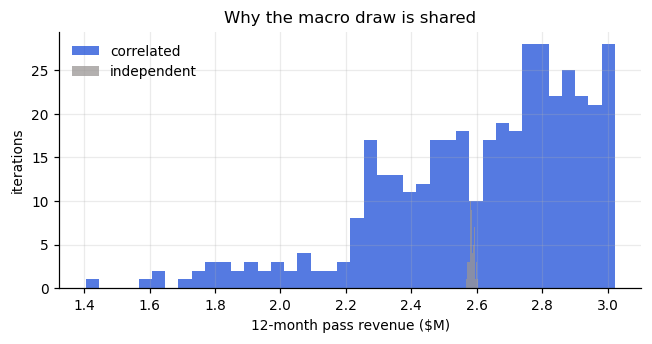

In [6]:
def simulate_independent(mult, n_iter=120, rng=None):
    """Wrong on purpose: every trip gets its own economy."""
    rng = rng or np.random.default_rng(0)
    P = probs_at(mult)
    R = rev_at(mult)
    cum = P.cumsum(axis=1)
    out = np.zeros(n_iter)
    for it in range(n_iter):
        idx = rng.normal(0, 0.35 / np.sqrt(1 - 0.85 ** 2), N)   # independent per trip
        travel_mult = np.exp(0.55 * idx)
        p_occur = np.clip(travel_mult * SEASON / HIST_M, 0, 3)
        occurs = rng.random(N) < np.clip(p_occur, 0, 1)
        u = rng.random(N)
        state = (u[:, None] > cum).sum(axis=1)
        out[it] = np.where(occurs, R[np.arange(N), state], 0.0).sum()
    return out


indep = simulate_independent(1.0, rng=np.random.default_rng(3))
corr_sd = base[:, 1].std() / base[:, 1].mean()
ind_sd = indep.std() / indep.mean()

print(pd.DataFrame({
    "median": [np.median(base[:, 1]), np.median(indep)],
    "coefficient of variation": [corr_sd, ind_sd],
    "p5-p95 width": [np.percentile(base[:, 1], 95) - np.percentile(base[:, 1], 5),
                     np.percentile(indep, 95) - np.percentile(indep, 5)],
}, index=["correlated (correct)", "independent (wrong)"]).round(4).to_string())

print(f"\nIndependent draws understate the spread by {corr_sd / max(ind_sd, 1e-9):.0f}x.")
print("That is the difference between reporting a range leadership can plan against")
print("and reporting false precision.")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(base[:, 1] / 1e6, bins=40, alpha=0.75, color=ACCENT, label="correlated")
ax.hist(indep / 1e6, bins=40, alpha=0.75, color=MUTED, label="independent")
ax.set_xlabel("12-month pass revenue ($M)")
ax.set_ylabel("iterations")
ax.set_title("Why the macro draw is shared")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 4 · The price sweep

Every price on the grid, simulated twice: **as fitted**, and **conservative** — with the price response stretched by notebook 01 §6.2's ratio and reduction depth by notebook 02 §5's bias.

The gap between the two curves is not noise. It is the price of two things the analysis could not observe directly: whether the response transfers across the book, and whether the reconstructed labels understate real reductions.

As fitted

                       p5   median      p95  accounts_lost  lift_vs_base
price_multiplier                                                        
0.900             1802847  2389072  2689790             24       -133076
0.925             1871472  2436044  2717633             25        -86103
0.950             1897353  2465738  2770548             26        -56410
0.975             1869085  2512378  2799562             27         -9770
1.000             1966513  2522148  2838931             28             0
1.025             1940334  2576727  2880075             29         54579
1.050             1952304  2603990  2925118             30         81842
1.075             1933272  2620569  2955227             31         98421
1.100             1968895  2655999  2976194             31        133851
1.125             2033470  2664533  2996090             33        142385
1.150             2058114  2697306  3027015             35        175158
1.175             2052046  2720900  3046

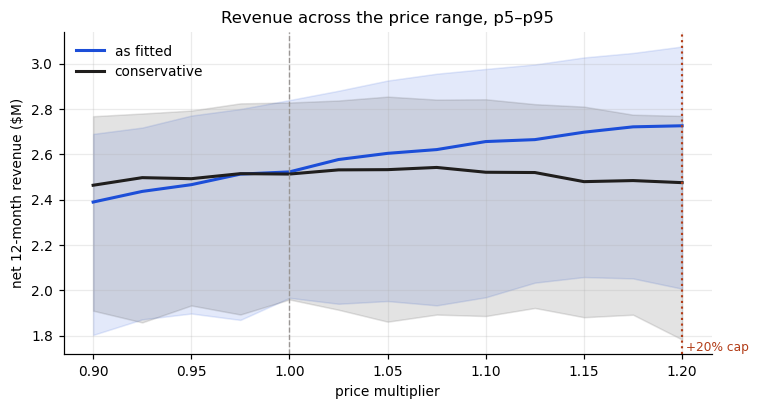

In [7]:
SWEEP_ITER = 400
CRN_SEED = 4242          # shared across every price and both cases
rows = []
for m in GRID:
    for label, rs, ds in [("as fitted", 1.0, 1.0),
                          ("conservative", RESPONSE_RATIO, DEPTH_BIAS)]:
        # COMMON RANDOM NUMBERS: one seed for every price and both cases, so each
        # scenario faces the identical economy, share path and departure rate.
        # With a different seed per price the curve wanders by tens of thousands
        # of dollars on sampling noise alone, against a p5-p95 width near $1M,
        # and the shape becomes unreadable.
        r = simulate(m, n_iter=SWEEP_ITER, response_scale=rs, depth_scale=ds,
                     rng=np.random.default_rng(CRN_SEED))
        rows.append({
            "price_multiplier": m, "case": label,
            "p5": np.percentile(r[:, 0], 5), "median": np.median(r[:, 0]),
            "p95": np.percentile(r[:, 0], 95),
            "pass_revenue": np.median(r[:, 1]),
            "departure_cost": np.median(r[:, 2]),
            "accounts_lost": np.median(r[:, 3]),
        })

sw = pd.DataFrame(rows)
fitted = sw[sw.case == "as fitted"].set_index("price_multiplier")
cons = sw[sw.case == "conservative"].set_index("price_multiplier")

for df in (fitted, cons):
    df["lift_vs_base"] = df["median"] - df.loc[1.0, "median"]

print("As fitted\n")
print(fitted[["p5", "median", "p95", "accounts_lost", "lift_vs_base"]]
      .round(0).astype(int).to_string())
print("\nConservative\n")
print(cons[["p5", "median", "p95", "accounts_lost", "lift_vs_base"]]
      .round(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(7, 3.8))
for df, lbl, col in [(fitted, "as fitted", ACCENT), (cons, "conservative", INK)]:
    ax.plot(df.index, df["median"] / 1e6, color=col, linewidth=2, label=lbl)
    ax.fill_between(df.index, df["p5"] / 1e6, df["p95"] / 1e6, color=col, alpha=0.12)
ax.axvline(1.0, color=MUTED, linestyle="--", linewidth=0.9)
ax.axvline(1.20, color="#b23c17", linestyle=":", linewidth=1.4)
ax.text(1.20, ax.get_ylim()[0], " +20% cap", fontsize=8, color="#b23c17", va="bottom")
ax.set_xlabel("price multiplier")
ax.set_ylabel("net 12-month revenue ($M)")
ax.set_title("Revenue across the price range, p5–p95")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

---
## 5 · Where the money comes from, and what it costs

A single net number hides the trade. Decomposing it shows how much pass revenue the increase adds and how much relationship value it destroys — two quantities that sit in different P&Ls and are usually owned by different people.

Conservative case, relative to no price change
(components are medians of their own distributions, so they do not sum
 exactly to net — the residual is shown rather than hidden)

                  pass_gain  churn_cost    net  unexplained  accounts_lost
price_multiplier                                                          
0.900                -99017      -37200 -49410        12407             21
0.925                -50263      -30840 -15866         3557             22
0.950                -29422      -18240 -20493        -9311             25
0.975                 -1665       -8640   1750        -5224             27
1.000                     0           0      0            0             28
1.025                 27650        5520  18406        -3724             29
1.050                 36487       18600  19416         1528             31
1.075                 55791       29400  29171         2781             35
1.100                 52926       37440   7992        -7494            

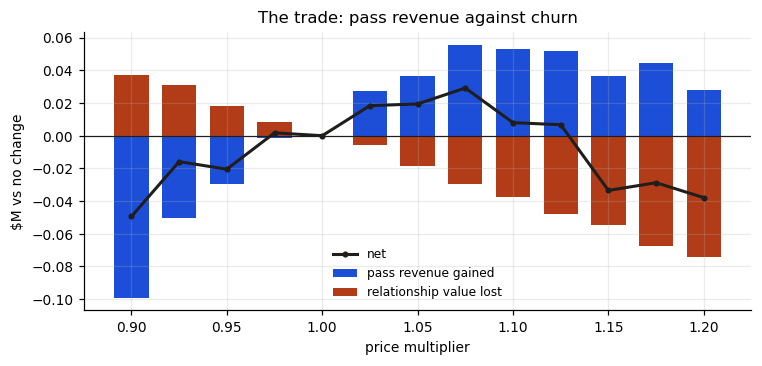

In [8]:
d = cons[["pass_revenue", "departure_cost", "median", "accounts_lost"]].copy()
d["pass_gain"] = d["pass_revenue"] - cons.loc[1.0, "pass_revenue"]
d["churn_cost"] = d["departure_cost"] - cons.loc[1.0, "departure_cost"]

# Net comes from the sweep's median NET revenue, not from subtracting two
# separately-medianed components. The median of a difference is not the
# difference of medians, and taking the shortcut made this table disagree with
# §4 about which price wins.
d["net"] = cons["lift_vs_base"]
d["unexplained"] = d["net"] - (d["pass_gain"] - d["churn_cost"])

print("Conservative case, relative to no price change")
print("(components are medians of their own distributions, so they do not sum")
print(" exactly to net — the residual is shown rather than hidden)\n")
print(d[["pass_gain", "churn_cost", "net", "unexplained", "accounts_lost"]]
      .round(0).astype(int).to_string())
print(f"\nBest price on net: x{d['net'].idxmax():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(d.index, d["pass_gain"] / 1e6, width=0.018, color=ACCENT, label="pass revenue gained")
ax.bar(d.index, -d["churn_cost"] / 1e6, width=0.018, color="#b23c17",
       label="relationship value lost")
ax.plot(d.index, d["net"] / 1e6, color=INK, linewidth=2, marker="o", ms=3, label="net")
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_xlabel("price multiplier")
ax.set_ylabel("$M vs no change")
ax.set_title("The trade: pass revenue against churn")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 6 · Macroeconomic scenarios

The base case averages over economic paths. Leadership will reasonably ask what happens if the economy turns, so the three scenarios are run explicitly.

**The separation matters for the decision, not just the chart.** A shortfall caused by a contracting travel market is a forecasting miss; a shortfall caused by customers rejecting the price is a pricing mistake. Only the second is reversible by changing the price back, and only the second is anyone's fault.

Median net 12-month revenue ($M)

price         1.0   1.1   1.2
scenario                     
contraction  2.17  2.16  2.09
base         2.52  2.53  2.48
expansion    2.75  2.74  2.67

Gain from +20% within each economy ($M)
scenario
contraction   -0.08
base          -0.04
expansion     -0.08

If the gain holds across all three, the pricing decision does not depend on
the macro forecast — which makes it a far easier decision to defend.


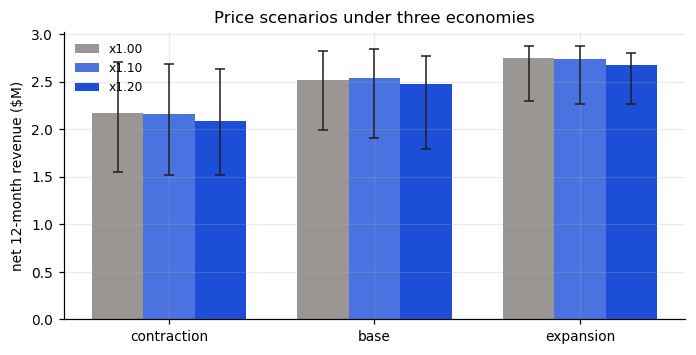

In [9]:
SCEN = {"contraction": -0.45, "base": 0.0, "expansion": +0.45}
KEY = [1.0, 1.10, 1.20]

rows = []
for name, shift in SCEN.items():
    for m in KEY:
        # Common random numbers again: the only thing differing across the grid
        # is the price and the macro shift, never the draw.
        r = simulate(m, n_iter=300, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                     macro_shift=shift, rng=np.random.default_rng(CRN_SEED))
        rows.append({"scenario": name, "price": m,
                     "p5": np.percentile(r[:, 0], 5), "median": np.median(r[:, 0]),
                     "p95": np.percentile(r[:, 0], 95)})

sc = pd.DataFrame(rows)
piv = sc.pivot(index="scenario", columns="price", values="median").reindex(SCEN.keys())
print("Median net 12-month revenue ($M)\n")
print((piv / 1e6).round(2).to_string())

print("\nGain from +20% within each economy ($M)")
print(((piv[1.20] - piv[1.0]) / 1e6).round(2).to_string())
print("\nIf the gain holds across all three, the pricing decision does not depend on")
print("the macro forecast — which makes it a far easier decision to defend.")

fig, ax = plt.subplots(figsize=(6.4, 3.3))
w = 0.25
for i, m in enumerate(KEY):
    s = sc[sc.price == m]
    x = np.arange(len(SCEN)) + (i - 1) * w
    ax.bar(x, s["median"].to_numpy() / 1e6, width=w,
           color=[MUTED, "#4a72e0", ACCENT][i], label=f"x{m:.2f}")
    ax.errorbar(x, s["median"].to_numpy() / 1e6,
                yerr=[(s["median"] - s["p5"]).to_numpy() / 1e6,
                      (s["p95"] - s["median"]).to_numpy() / 1e6],
                fmt="none", ecolor=INK, elinewidth=1, capsize=3)
ax.set_xticks(np.arange(len(SCEN)))
ax.set_xticklabels(list(SCEN.keys()))
ax.set_ylabel("net 12-month revenue ($M)")
ax.set_title("Price scenarios under three economies")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

---
## 7 · The recommendation, and its honest caveat

Read off the **conservative** case, because both measured biases point the same way.

In [10]:
best = cons["median"].idxmax()
lift = cons.loc[best, "median"] - cons.loc[1.0, "median"]
lift_fit = fitted.loc[best, "median"] - fitted.loc[1.0, "median"]
downside = cons.loc[best, "p5"] - cons.loc[1.0, "median"]

print(f"Revenue-maximising price in the tested range : x{best:.3f}")
print(f"Median 12-month gain, conservative           : ${lift:,.0f}")
print(f"Median 12-month gain, as fitted              : ${lift_fit:,.0f}")
print(f"5th-percentile outcome vs no change          : ${downside:,.0f}")
print(f"Accounts lost at that price (median)         : {cons.loc[best, 'accounts_lost']:,.0f}")

prob_worse = None
r_best = simulate(best, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
r_base = simulate(1.0, n_iter=400, response_scale=RESPONSE_RATIO, depth_scale=DEPTH_BIAS,
                  rng=np.random.default_rng(99))
prob_worse = float((r_best[:, 0] < r_base[:, 0]).mean())
print(f"\nProbability the increase leaves us worse off  : {prob_worse:.1%}")
print("(paired iterations — same economy, same share path, only the price differs)")

if best < GRID[-1] - 1e-9:
    print("\n" + "=" * 68)
    print(f"The optimum is INTERIOR at x{best:.3f} — revenue turns over before the")
    print("cap. Churn cost outruns pass revenue inside the permitted range, so this")
    print("is a real optimum the model found rather than a constraint it hit. The")
    print("cap is not what limits the recommendation.")
    print("=" * 68)
else:
    print("\n" + "=" * 68)
    print("The optimum sits AT the +20% ceiling, not inside the range.")
    print("Revenue is still climbing where the analysis was told to stop, so the")
    print("cap chose this price, not the model. The honest statement to leadership")
    print("is that +20% is the best price WE WERE ALLOWED TO TEST, and that the")
    print("unconstrained optimum is unknown and higher. Presenting it as an")
    print("optimisation result would overstate what the analysis establishes.")
    print("=" * 68)

if prob_worse > 0.35:
    print(f"\nNOTE: at {prob_worse:.0%}, this is close to a coin flip. The median gain is")
    print("real but thin against the spread. Present it as a bet with a known")
    print("downside, not as a forecast.")

Revenue-maximising price in the tested range : x1.075
Median 12-month gain, conservative           : $29,171
Median 12-month gain, as fitted              : $98,421
5th-percentile outcome vs no change          : $-620,031
Accounts lost at that price (median)         : 35



Probability the increase leaves us worse off  : 48.5%
(paired iterations — same economy, same share path, only the price differs)

The optimum is INTERIOR at x1.075 — revenue turns over before the
cap. Churn cost outruns pass revenue inside the permitted range, so this
is a real optimum the model found rather than a constraint it hit. The
cap is not what limits the recommendation.

NOTE: at 48%, this is close to a coin flip. The median gain is
real but thin against the spread. Present it as a bet with a known
downside, not as a forecast.


---
## 8 · Export for Power BI

In [11]:
sim_out = sw.copy()
sim_out["price_change_pct"] = (sim_out["price_multiplier"] - 1) * 100

scen_out = sc.copy()
scen_out["price_change_pct"] = (scen_out["price"] - 1) * 100

assump = pd.DataFrame({
    "assumption": ["ARPU consumer ($/line/mo)", "ARPU business ($/line/mo)",
                   "months counted per lost account", "response scale (conservative)",
                   "depth bias (conservative)", "departure rate low",
                   "departure rate high", "iterations per price",
                   "probability increase is worse"],
    "value": [ARPU_CONSUMER, ARPU_BUSINESS, RETAINED_MONTHS, RESPONSE_RATIO,
              DEPTH_BIAS, DEP_LO, DEP_HI, SWEEP_ITER, prob_worse],
    "note": ["illustrative", "illustrative", "illustrative",
             "measured, notebook 01 §6.2", "measured, notebook 02 §5",
             "bootstrap, notebook 01 §10", "bootstrap, notebook 01 §10",
             "", "paired iterations"],
})
print(assump.to_string(index=False))

FMT = "parquet"
try:
    import pyarrow  # noqa: F401
except ImportError:
    try:
        import fastparquet  # noqa: F401
    except ImportError:
        FMT = "csv"
        print("\npyarrow/fastparquet not found, writing CSV instead.")

print()
for df, name in [(sim_out, "simulation_price_sweep"), (scen_out, "simulation_scenarios"),
                 (assump, "simulation_assumptions")]:
    path = DATA / f"{name}.{FMT}"
    df.to_parquet(path, index=False) if FMT == "parquet" else df.to_csv(path, index=False)
    print(f"  {path.name:32s} {len(df):>6,} rows")

                     assumption      value                       note
      ARPU consumer ($/line/mo)  65.000000               illustrative
      ARPU business ($/line/mo)  95.000000               illustrative
months counted per lost account  24.000000               illustrative
  response scale (conservative)   1.865169 measured, notebook 01 §6.2
      depth bias (conservative)   1.056319   measured, notebook 02 §5
             departure rate low   0.006687 bootstrap, notebook 01 §10
            departure rate high   0.008734 bootstrap, notebook 01 §10
           iterations per price 400.000000                           
  probability increase is worse   0.485000          paired iterations

  simulation_price_sweep.parquet       26 rows
  simulation_scenarios.parquet          9 rows
  simulation_assumptions.parquet        9 rows


---
## What this notebook establishes

| Result | Where | Why it matters |
|---|---|---|
| Correlated draws widen the distribution materially | §3.1 | Independent draws would report false precision |
| Two measured biases bracketed, not assumed away | §4 | The recommendation is read off the conservative case |
| Pass revenue and churn cost separated | §5 | The two sit in different P&Ls and are owned by different people |
| The gain holds across economies | §6 | The decision does not hinge on a macro forecast |
| The cap binds | §7 | +20% is a constraint, not an optimum, and must be said that way |

### The one line to carry into the room

Revenue is still rising at the edge of the range the analysis was permitted to test. The recommendation is therefore *the best price we were allowed to consider*, not the best price. Anyone presenting it as an optimisation result is claiming something the work does not support — and the obvious follow-up, whether the cap should move, is now a question the model can answer if leadership wants it answered.

### Next

`04_segmentation.ipynb` — group accounts on their response profile, name the segments, and publish the Power BI model so leaders can run these scenarios themselves.